# 一般化線形モデル（GLM）ハンズオン

GLMは`family`を変えるだけで、線形回帰・ポアソン回帰・ロジスティック回帰を統一的な枠組みで扱える。本資料では以下の3つのデータを用いる:

1. **ToothGrowth**（線形回帰, `family = gaussian`）: ビタミンCの用量・投与法と歯の成長の関係
2. **esoph**（ポアソン回帰, `family = poisson`）: 食道癌の症例数とアルコール・タバコ摂取量
3. **MASS::birthwt**（ロジスティック回帰, `family = binomial`）: 低出生体重児のリスク因子

いずれも以下の共通パターンで分析する:

**データ確認 → `glm()` → `summary()` → 可視化**

# パッケージの読み込み

In [1]:
library("MASS")

---
# 1. 線形回帰（family = gaussian）: ToothGrowth

ビタミンCの投与がモルモットの歯の成長に与える影響を調べた実験データ。

| 変数 | 説明 |
|------|------|
| `len` | 歯の長さ（連続値、応答変数） |
| `supp` | 投与法（OJ=オレンジジュース、VC=アスコルビン酸） |
| `dose` | 用量（0.5, 1.0, 2.0 mg/day） |

連続値の応答変数 → 正規分布を仮定 → `family = gaussian`（線形回帰と等価）

## データの確認

In [2]:
data(ToothGrowth)
str(ToothGrowth)
head(ToothGrowth)
summary(ToothGrowth)

'data.frame':	60 obs. of  3 variables:
 $ len : num  4.2 11.5 7.3 5.8 6.4 10 11.2 11.2 5.2 7 ...
 $ supp: Factor w/ 2 levels "OJ","VC": 2 2 2 2 2 2 2 2 2 2 ...
 $ dose: num  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 ...


,len,supp,dose
,<dbl>,<fct>,<dbl>
1,4.2,VC,0.5
2,11.5,VC,0.5
3,7.3,VC,0.5
4,5.8,VC,0.5
5,6.4,VC,0.5
6,10.0,VC,0.5


      len        supp         dose      
 Min.   : 4.20   OJ:30   Min.   :0.500  
 1st Qu.:13.07   VC:30   1st Qu.:0.500  
 Median :19.25           Median :1.000  
 Mean   :18.81           Mean   :1.167  
 3rd Qu.:25.27           3rd Qu.:2.000  
 Max.   :33.90           Max.   :2.000  

## 生データの可視化

用量が増えるほど歯が長くなる傾向があるか、投与法による差があるかを確認する。

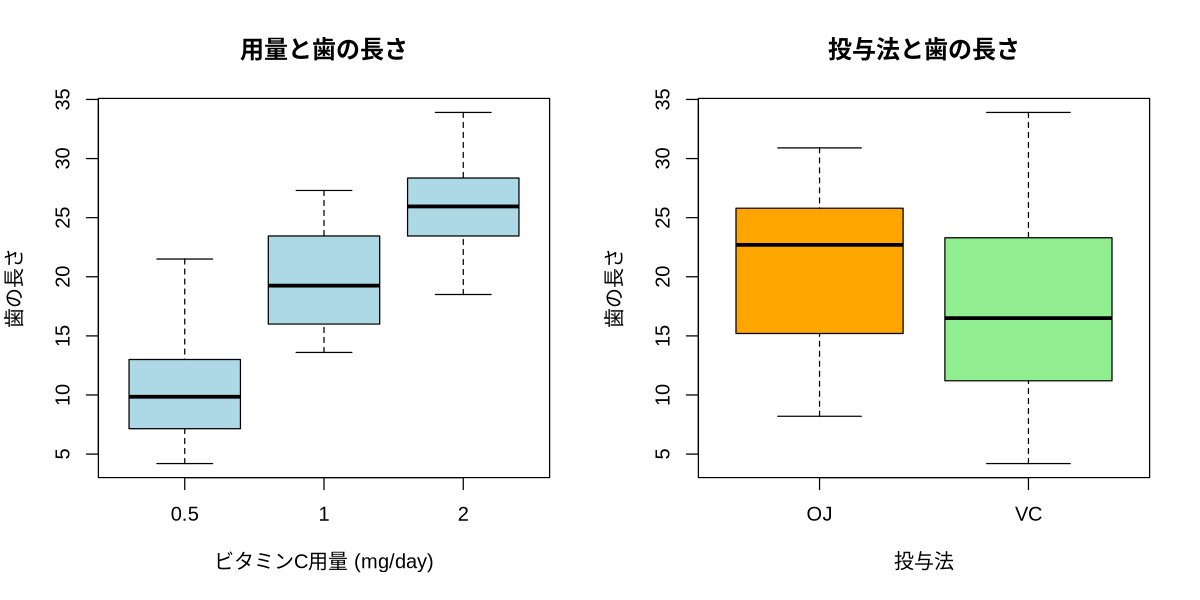

In [3]:
options(repr.plot.width=10, repr.plot.height=5)
par(mfrow=c(1,2))

# 箱ひげ図: 用量ごとの歯の長さ
boxplot(len ~ dose, data=ToothGrowth,
    col="lightblue", main="用量と歯の長さ",
    xlab="ビタミンC用量 (mg/day)", ylab="歯の長さ")

# 箱ひげ図: 投与法ごとの歯の長さ
boxplot(len ~ supp, data=ToothGrowth,
    col=c("orange", "lightgreen"), main="投与法と歯の長さ",
    xlab="投与法", ylab="歯の長さ")

par(mfrow=c(1,1))

### 箱ひげ図の解釈

- **左図（用量）**: 用量が0.5→1.0→2.0と増えるにつれ、歯の長さの中央値が明確に増加 → **用量反応関係（dose-response）が存在する**
- **右図（投与法）**: OJ（オレンジジュース）の方がVC（アスコルビン酸）より中央値がやや高い → 投与法によって効果に差がある可能性

## モデルの構築

```r
glm(応答変数 ~ 説明変数, family = 分布族, data = データ)
```

`gaussian`: 正規分布（恒等リンク関数）→ 通常の線形回帰と同じ。

In [4]:
fit_gauss <- glm(len ~ dose + supp, family = gaussian, data = ToothGrowth)

## 結果の確認

`summary()` の読み方:

- **Coefficients** テーブル:
  - `Estimate`: 回帰係数の推定値
    - `(Intercept)`: 切片（dose=0, supp=OJのときの予測値）
    - `dose`: 用量が1 mg/day増えたときの歯の長さの変化量
    - `suppVC`: OJに対するVCの効果の差（OJが基準）
  - `Std. Error`: 標準誤差（推定値の不確かさ）
  - `t value`: t統計量（Estimate / Std. Error）
  - `Pr(>|t|)`: p値（帰無仮説「係数=0」の検定）
- **Null deviance**: 帰無モデル（切片のみ）の逸脱度
- **Residual deviance**: 構築したモデルの逸脱度（小さいほど良い）
- **AIC**: 赤池情報量基準（モデル比較に使用、小さいほど良い）

In [5]:
summary(fit_gauss)


Call:
glm(formula = len ~ dose + supp, family = gaussian, data = ToothGrowth)

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   9.2725     1.2824   7.231 1.31e-09 ***
dose          9.7636     0.8768  11.135 6.31e-16 ***
suppVC       -3.7000     1.0936  -3.383   0.0013 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for gaussian family taken to be 17.93956)

    Null deviance: 3452.2  on 59  degrees of freedom
Residual deviance: 1022.6  on 57  degrees of freedom
AIC: 348.42

Number of Fisher Scoring iterations: 2


### summary() の結果の解釈

- **dose**: Estimate=9.764, p<0.001 *** → 用量が1 mg/day増えると歯の長さが約9.8単位伸びる（非常に強い効果）
- **suppVC**: Estimate=-3.700, p=0.001 ** → VCはOJに比べて歯の長さが約3.7単位短い（OJの方が効果が高い）
- **Null deviance=3452 → Residual deviance=1023** → モデルによって逸脱度が大幅に減少 → 説明変数がよく効いている

## 回帰係数の信頼区間

95%信頼区間にゼロが含まれなければ、その変数は有意に効果がある。

In [6]:
confint(fit_gauss)

Waiting for profiling to be done...



,2.5 %,97.5 %
(Intercept),6.759111,11.785889
dose,8.045008,11.482135
suppVC,-5.843425,-1.556575


### 信頼区間の解釈

- **dose**: [8.05, 11.48] → ゼロを含まない → 用量の効果は有意
- **suppVC**: [-5.84, -1.56] → ゼロを含まない → 投与法の差も有意
- いずれも信頼区間の幅が比較的狭く、推定が安定している

## 予測値の可視化

モデルの予測値と実測値を重ねて表示する。投与法ごとに回帰直線がどのように異なるかを確認する。

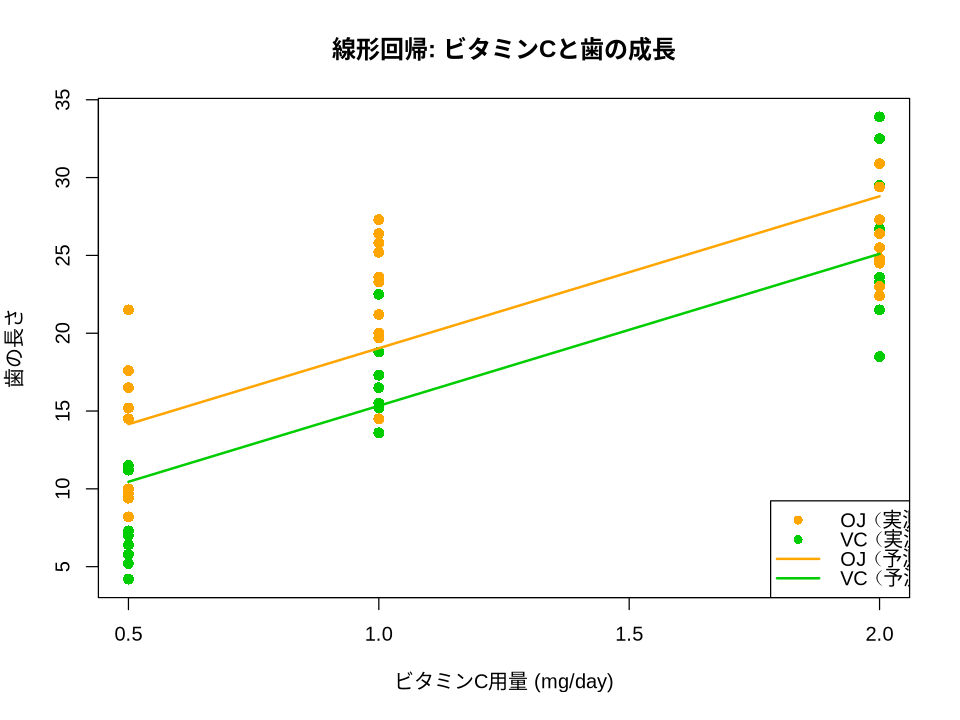

In [7]:
options(repr.plot.width=8, repr.plot.height=6)
dose_seq <- seq(0.5, 2.0, length.out=100)

# 投与法ごとに予測値を計算
pred_OJ <- predict(fit_gauss,
    newdata=data.frame(dose=dose_seq, supp="OJ"), type="response")
pred_VC <- predict(fit_gauss,
    newdata=data.frame(dose=dose_seq, supp="VC"), type="response")

# 実測値のプロット
plot(len ~ dose, data=ToothGrowth,
    col=ifelse(ToothGrowth$supp == "OJ", "orange", "green3"),
    pch=16, cex=1.2,
    main="線形回帰: ビタミンCと歯の成長",
    xlab="ビタミンC用量 (mg/day)", ylab="歯の長さ")

# 予測値の回帰直線
lines(dose_seq, pred_OJ, col="orange", lwd=2)
lines(dose_seq, pred_VC, col="green3", lwd=2)
legend("bottomright", legend=c("OJ（実測）", "VC（実測）",
    "OJ（予測）", "VC（予測）"),
    col=c("orange", "green3", "orange", "green3"),
    pch=c(16, 16, NA, NA), lty=c(NA, NA, 1, 1), lwd=2)

### 予測値プロットの解釈

- OJ（橙線）とVC（緑線）は**平行な2本の直線** → `supp` は切片のみに影響し、傾き（用量反応の強さ）は同じと仮定している
- OJ線がVC線より常に上 → **同じ用量ならOJの方が歯の成長を促進**
- 用量0.5付近では実測値にばらつきが大きいが、用量2.0付近ではOJとVCの差が縮まる傾向も見られる → 交互作用項（`dose:supp`）を入れるとさらに良いモデルになる可能性

---
# 2. ポアソン回帰（family = poisson）: esoph

フランスのイル=エ=ヴィレーヌ県における食道癌の症例対照研究データ。

| 変数 | 説明 |
|------|------|
| `ncases` | 食道癌の症例数（カウントデータ、応答変数） |
| `ncontrols` | 対照群の人数 |
| `agegp` | 年齢層（25-34, 35-44, 45-54, 55-64, 65-74, 75+） |
| `alcgp` | アルコール摂取量（0-39, 40-79, 80-119, 120+ g/day） |
| `tobgp` | タバコ摂取量（0-9, 10-19, 20-29, 30+ g/day） |

カウントデータ → ポアソン分布を仮定 → `family = poisson`

リンク関数は対数: `log(μ) = β0 + β1*x1 + ...`

## データの確認

In [8]:
data(esoph)
str(esoph)
head(esoph, 10)
summary(esoph)

'data.frame':	88 obs. of  5 variables:
 $ agegp    : Ord.factor w/ 6 levels "25-34"<"35-44"<..: 1 1 1 1 1 1 1 1 1 1 ...
 $ alcgp    : Ord.factor w/ 4 levels "0-39g/day"<"40-79"<..: 1 1 1 1 2 2 2 2 3 3 ...
 $ tobgp    : Ord.factor w/ 4 levels "0-9g/day"<"10-19"<..: 1 2 3 4 1 2 3 4 1 2 ...
 $ ncases   : num  0 0 0 0 0 0 0 0 0 0 ...
 $ ncontrols: num  40 10 6 5 27 7 4 7 2 1 ...


,agegp,alcgp,tobgp,ncases,ncontrols
,<ord>,<ord>,<ord>,<dbl>,<dbl>
1,25-34,0-39g/day,0-9g/day,0,40
2,25-34,0-39g/day,10-19,0,10
3,25-34,0-39g/day,20-29,0,6
4,25-34,0-39g/day,30+,0,5
5,25-34,40-79,0-9g/day,0,27
6,25-34,40-79,10-19,0,7
7,25-34,40-79,20-29,0,4
8,25-34,40-79,30+,0,7
9,25-34,80-119,0-9g/day,0,2


   agegp          alcgp         tobgp        ncases         ncontrols     
 25-34:15   0-39g/day:23   0-9g/day:24   Min.   : 0.000   Min.   : 0.000  
 35-44:15   40-79    :23   10-19   :24   1st Qu.: 0.000   1st Qu.: 1.000  
 45-54:16   80-119   :21   20-29   :20   Median : 1.000   Median : 4.000  
 55-64:16   120+     :21   30+     :20   Mean   : 2.273   Mean   : 8.807  
 65-74:15                                3rd Qu.: 4.000   3rd Qu.:10.000  
 75+  :11                                Max.   :17.000   Max.   :60.000  

## 生データの可視化

各要因ごとの症例数の分布を確認する。

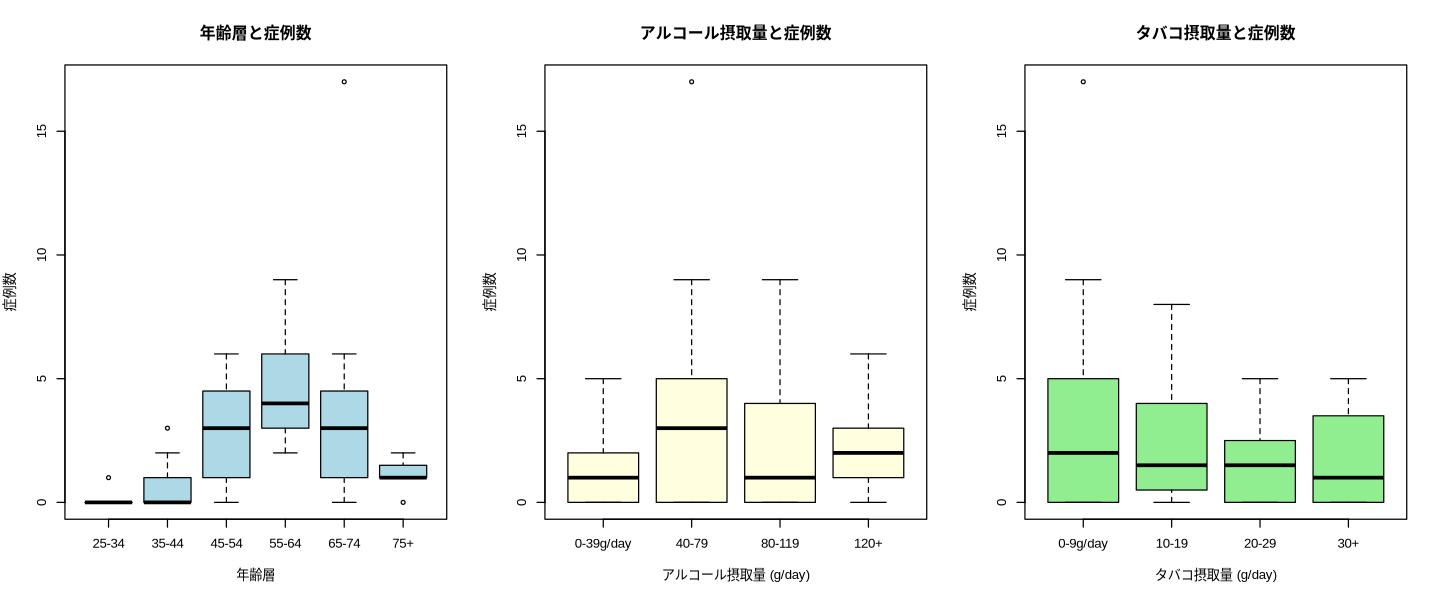

In [9]:
options(repr.plot.width=12, repr.plot.height=5)
par(mfrow=c(1,3))

# 年齢層ごとの症例数
boxplot(ncases ~ agegp, data=esoph, col="lightblue",
    main="年齢層と症例数",
    xlab="年齢層", ylab="症例数")

# アルコール摂取量ごとの症例数
boxplot(ncases ~ alcgp, data=esoph, col="lightyellow",
    main="アルコール摂取量と症例数",
    xlab="アルコール摂取量 (g/day)", ylab="症例数")

# タバコ摂取量ごとの症例数
boxplot(ncases ~ tobgp, data=esoph, col="lightgreen",
    main="タバコ摂取量と症例数",
    xlab="タバコ摂取量 (g/day)", ylab="症例数")

par(mfrow=c(1,1))

### 生データの解釈

- **左図（年齢層）**: 55-64歳をピークに症例数が多い。75+歳で減少するのは母集団が小さくなるため（死亡による脱落バイアス）
- **中図（アルコール）**: 120+ g/dayの群で症例数が増加する傾向があるが、ばらつきも大きい
- **右図（タバコ）**: タバコ摂取量と症例数の関係は単純ではない。0-9 g/dayの群に外れ値（高い症例数）がある

## モデルの構築

`poisson`: ポアソン分布（対数リンク関数）→ ポアソン回帰。

順序因子を数値に変換して使用し、線形な用量反応関係を仮定する。

In [10]:
# 順序因子を数値に変換
esoph$alcgp_num <- as.numeric(esoph$alcgp)
esoph$tobgp_num <- as.numeric(esoph$tobgp)
esoph$agegp_num <- as.numeric(esoph$agegp)

fit_pois <- glm(ncases ~ agegp_num + alcgp_num + tobgp_num,
    family = poisson, data = esoph)

## 結果の確認

`summary()` の読み方（ポアソン回帰特有の点）:

- **Coefficients** テーブル:
  - `Estimate`: **対数リスク比**（対数スケールでの変化量）
    - `agegp_num`: 年齢層が1段階上がるごとの対数期待値の変化
    - `alcgp_num`: アルコール摂取が1段階増えるごとの対数期待値の変化
    - `tobgp_num`: タバコ摂取が1段階増えるごとの対数期待値の変化

**解釈のコツ**: `Estimate` を `exp()` するとリスク比（rate ratio）になる。

例: `alcgp_num` の Estimate=0.5 → `exp(0.5)=1.65` → アルコール摂取が1段階増えると期待症例数が1.65倍。

### 過分散の確認

`Residual deviance / 残差自由度 ≈ 1` なら問題なし。1より大幅に大きい場合は過分散 → 負の二項分布などを検討する。

In [11]:
summary(fit_pois)


Call:
glm(formula = ncases ~ agegp_num + alcgp_num + tobgp_num, family = poisson, 
    data = esoph)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  0.23607    0.30586   0.772 0.440227    
agegp_num    0.24623    0.04478   5.499 3.82e-08 ***
alcgp_num    0.07975    0.06357   1.254 0.209666    
tobgp_num   -0.23773    0.06722  -3.536 0.000406 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 262.93  on 87  degrees of freedom
Residual deviance: 212.63  on 84  degrees of freedom
AIC: 390.33

Number of Fisher Scoring iterations: 6


### summary() の結果の解釈

- **agegp_num**: Estimate=0.246, p<0.001 *** → 年齢層が1段階上がるごとに症例数の対数が0.25増加（**強い効果**）
- **alcgp_num**: Estimate=0.080, p=0.210 → アルコール摂取量の効果は**有意でない**（意外な結果）。他の変数で調整すると単独の効果が弱まった可能性
- **tobgp_num**: Estimate=-0.238, p<0.001 *** → タバコ摂取が増えると症例数が**減少**（直感に反する結果）。交絡因子の影響や、集計データ特有の問題（Simpson's paradox）の可能性

## 過分散の確認

In [12]:
# Residual deviance / df が1より大幅に大きければ過分散の可能性
deviance(fit_pois) / fit_pois$df.residual

[1] 2.53129

### 過分散の解釈

Residual deviance / df = **2.53** → 1よりかなり大きい → **過分散あり**

ポアソン分布の仮定（平均=分散）が成り立っていない。負の二項分布（`MASS::negative.binomial`）や準ポアソン（`family = quasipoisson`）の使用を検討すべき。ただし本資料ではGLMの枠組みの紹介が目的なので、このまま進める。

## リスク比と信頼区間

`exp(係数)` = リスク比:
- **1より大** → リスク増加
- **1より小** → リスク減少
- 95%信頼区間に**1が含まれなければ有意**

In [13]:
cbind(
    RateRatio = exp(coef(fit_pois)),
    exp(confint(fit_pois))
)

Waiting for profiling to be done...



,RateRatio,2.5 %,97.5 %
(Intercept),1.2662568,0.6865838,2.2784858
agegp_num,1.2791966,1.1727354,1.3980024
alcgp_num,1.0830133,0.9561881,1.2271046
tobgp_num,0.7884192,0.6898731,0.8981295


### リスク比の解釈

- **agegp_num**: RR=1.28 [1.17, 1.40] → 1を含まない → **年齢層が1段階上がると症例数が約28%増加**
- **alcgp_num**: RR=1.08 [0.96, 1.23] → 1を含む → 有意でない
- **tobgp_num**: RR=0.79 [0.69, 0.90] → 1を含まない → タバコ1段階増で症例数が約21%減少（**要注意: 交絡の可能性**）

## 予測値の可視化

各リスク因子を変化させたときの予測症例数。他の変数は中央値で固定する。

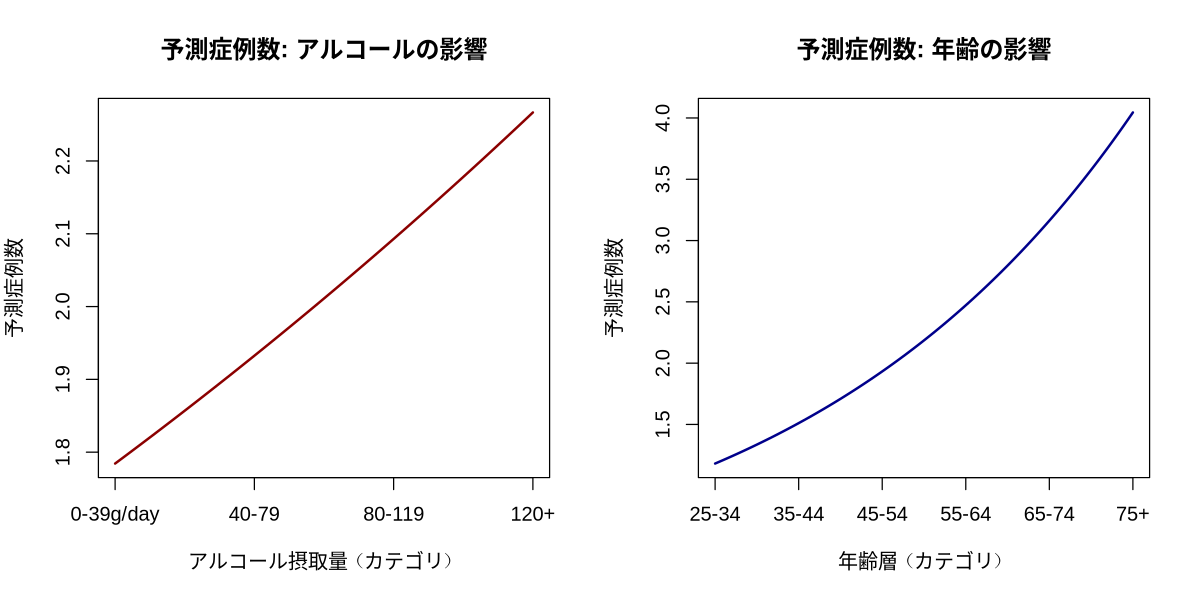

In [14]:
options(repr.plot.width=10, repr.plot.height=5)
par(mfrow=c(1,2))

# アルコール摂取量ごとの予測症例数
alcgp_seq <- seq(1, 4, length.out=100)
pred_alc <- predict(fit_pois,
    newdata=data.frame(
        agegp_num=median(esoph$agegp_num),
        alcgp_num=alcgp_seq,
        tobgp_num=median(esoph$tobgp_num)),
    type="response")

plot(alcgp_seq, pred_alc, type="l", col="darkred", lwd=2,
    main="予測症例数: アルコールの影響",
    xlab="アルコール摂取量（カテゴリ）", ylab="予測症例数",
    xaxt="n")
axis(1, at=1:4, labels=levels(esoph$alcgp))

# 年齢層ごとの予測症例数
agegp_seq <- seq(1, 6, length.out=100)
pred_age <- predict(fit_pois,
    newdata=data.frame(
        agegp_num=agegp_seq,
        alcgp_num=median(esoph$alcgp_num),
        tobgp_num=median(esoph$tobgp_num)),
    type="response")

plot(agegp_seq, pred_age, type="l", col="darkblue", lwd=2,
    main="予測症例数: 年齢の影響",
    xlab="年齢層（カテゴリ）", ylab="予測症例数",
    xaxt="n")
axis(1, at=1:6, labels=levels(esoph$agegp))

par(mfrow=c(1,1))

### 予測値プロットの解釈

**左図（アルコール）**:
- 摂取量の増加に伴い予測症例数がわずかに増加するが、統計的に有意でない
- 曲線の傾きが緩やか（指数関数的だが、係数が小さいため）

**右図（年齢）**:
- 年齢層が上がるにつれ予測症例数が**指数関数的に増加**
- 対数リンク関数のため、xの1単位増加がyの一定割合の増加に対応
- 25-34歳群では約0.5件だが、75+歳群では約3件と**6倍以上の差**

**注意**: ポアソン回帰の予測曲線は対数リンクのため、常に非負かつ指数的な形状になる

---
# 3. ロジスティック回帰（family = binomial）: birthwt

低出生体重児（2500g未満）のリスク因子を調べたデータ（Baystate Medical Center）。

| 変数 | 説明 |
|------|------|
| `low` | 低出生体重児かどうか（0=正常, 1=低体重、応答変数） |
| `age` | 母親の年齢 |
| `lwt` | 最終月経時の母親の体重（ポンド） |
| `smoke` | 妊娠中の喫煙（0=なし, 1=あり） |
| `ht` | 高血圧の既往（0=なし, 1=あり） |

二値の応答変数 → ベルヌーイ分布を仮定 → `family = binomial`（ロジスティック回帰）

リンク関数はロジット: `log(p/(1-p)) = β0 + β1*x1 + ...`

## データの確認

In [15]:
data(birthwt)
str(birthwt)
head(birthwt)

# 因子型への変換（カテゴリカル変数を明示する）
birthwt$smoke <- factor(birthwt$smoke, labels=c("非喫煙", "喫煙"))
birthwt$ht    <- factor(birthwt$ht, labels=c("なし", "あり"))

summary(birthwt[, c("low", "age", "lwt", "smoke", "ht")])

'data.frame':	189 obs. of  10 variables:
 $ low  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ age  : int  19 33 20 21 18 21 22 17 29 26 ...
 $ lwt  : int  182 155 105 108 107 124 118 103 123 113 ...
 $ race : int  2 3 1 1 1 3 1 3 1 1 ...
 $ smoke: int  0 0 1 1 1 0 0 0 1 1 ...
 $ ptl  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ ht   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ ui   : int  1 0 0 1 1 0 0 0 0 0 ...
 $ ftv  : int  0 3 1 2 0 0 1 1 1 0 ...
 $ bwt  : int  2523 2551 2557 2594 2600 2622 2637 2637 2663 2665 ...


,low,age,lwt,race,smoke,ptl,ht,ui,ftv,bwt
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
85,0,19,182,2,0,0,0,1,0,2523
86,0,33,155,3,0,0,0,0,3,2551
87,0,20,105,1,1,0,0,0,1,2557
88,0,21,108,1,1,0,0,1,2,2594
89,0,18,107,1,1,0,0,1,0,2600
91,0,21,124,3,0,0,0,0,0,2622


      low              age             lwt           smoke        ht     
 Min.   :0.0000   Min.   :14.00   Min.   : 80.0   非喫煙:115   なし:177  
 1st Qu.:0.0000   1st Qu.:19.00   1st Qu.:110.0   喫煙  : 74   あり: 12  
 Median :0.0000   Median :23.00   Median :121.0                          
 Mean   :0.3122   Mean   :23.24   Mean   :129.8                          
 3rd Qu.:1.0000   3rd Qu.:26.00   3rd Qu.:140.0                          
 Max.   :1.0000   Max.   :45.00   Max.   :250.0                          

## 生データの可視化

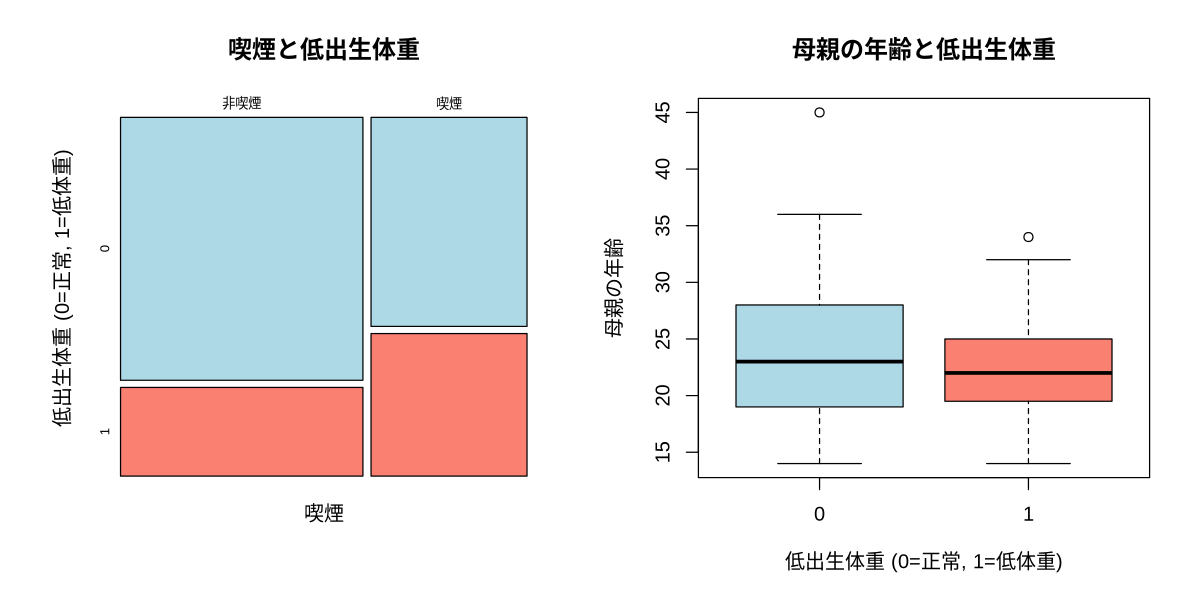

In [16]:
options(repr.plot.width=10, repr.plot.height=5)
par(mfrow=c(1,2))

# 喫煙と低出生体重の関係（モザイクプロット）
mosaicplot(table(birthwt$smoke, birthwt$low),
    main="喫煙と低出生体重",
    xlab="喫煙", ylab="低出生体重 (0=正常, 1=低体重)",
    col=c("lightblue", "salmon"))

# 母親の年齢と低出生体重の関係
boxplot(age ~ low, data=birthwt,
    col=c("lightblue", "salmon"),
    main="母親の年齢と低出生体重",
    xlab="低出生体重 (0=正常, 1=低体重)", ylab="母親の年齢")

par(mfrow=c(1,1))

### 生データの解釈

- **左図（モザイクプロット）**: 喫煙群の方が低出生体重（1）の割合がやや高い → 喫煙が低出生体重のリスク因子である可能性を示唆
- **右図（箱ひげ図）**: 正常群（0）と低体重群（1）で母親の年齢分布に大きな差はない → 年齢単独では低出生体重を強く予測しない可能性

## モデルの構築

`binomial`: 二項分布（ロジットリンク関数）→ ロジスティック回帰。

In [17]:
fit_binom <- glm(low ~ age + lwt + smoke + ht,
    family = binomial, data = birthwt)

## 結果の確認

`summary()` の読み方（ロジスティック回帰特有の点）:

- **Coefficients** テーブル:
  - `Estimate`: **ログオッズ比**（対数オッズの変化量）
    - `(Intercept)`: 全説明変数が基準カテゴリのときの対数オッズ
    - `age`: 年齢が1歳上がるごとの対数オッズの変化
    - `lwt`: 体重が1ポンド増えるごとの対数オッズの変化
    - `smoke喫煙`: 非喫煙に対する喫煙の対数オッズの変化
    - `htあり`: 高血圧なしに対するありの対数オッズの変化
  - `z value`: z統計量（正規近似による検定）
  - `Pr(>|z|)`: p値

**解釈のコツ**: `Estimate` を `exp()` するとオッズ比になる。

例: `smoke喫煙` の Estimate=0.5 → `exp(0.5)=1.65` → 喫煙者は非喫煙者に比べてリスクが1.65倍。

In [18]:
summary(fit_binom)


Call:
glm(formula = low ~ age + lwt + smoke + ht, family = binomial, 
    data = birthwt)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)   
(Intercept)  1.766856   1.052266   1.679  0.09313 . 
age         -0.035687   0.033365  -1.070  0.28480   
lwt         -0.016955   0.006623  -2.560  0.01047 * 
smoke喫煙    0.679020   0.331939   2.046  0.04079 * 
htあり       1.788156   0.685882   2.607  0.00913 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 234.67  on 188  degrees of freedom
Residual deviance: 215.68  on 184  degrees of freedom
AIC: 225.68

Number of Fisher Scoring iterations: 4


### summary() の結果の解釈

- **age**: Estimate=-0.036, p=0.285 → 年齢の効果は**有意でない**
- **lwt**: Estimate=-0.017, p=0.010 * → 体重が重いほどリスクが下がる（負の係数=**保護的効果**）
- **smoke喫煙**: Estimate=0.679, p=0.041 * → 喫煙者は低出生体重のリスクが**有意に高い**
- **htあり**: Estimate=1.788, p=0.009 ** → 高血圧の既往がある母親はリスクが非常に高い（**最も強い効果**）

## オッズ比と信頼区間

`exp(係数)` = オッズ比:
- **1より大** → リスク増加
- **1より小** → リスク減少
- 95%信頼区間に**1が含まれなければ有意**

In [19]:
cbind(
    OddsRatio = exp(coef(fit_binom)),
    exp(confint(fit_binom))
)

Waiting for profiling to be done...



,OddsRatio,2.5 %,97.5 %
(Intercept),5.8524230,0.7842478,49.3777332
age,0.9649420,0.9021332,1.0287735
lwt,0.9831878,0.9696802,0.9953419
smoke喫煙,1.9719451,1.0300303,3.7994096
htあり,5.9784194,1.6195662,25.2448818


### オッズ比の解釈

- **age**: OR=0.96 [0.90, 1.03] → 1を含む → 有意でない
- **lwt**: OR=0.98 [0.97, 1.00] → 1をわずかに含まない → 体重1ポンド増加ごとにリスクが約2%減少（わずかだが有意）
- **smoke喫煙**: OR=1.97 [1.03, 3.80] → 1を含まない → **喫煙者は非喫煙者の約2.0倍のリスク**
- **htあり**: OR=5.98 [1.62, 25.2] → 1を含まない → **高血圧がある母親は約6.0倍のリスク**（信頼区間が広い=症例が少ない）

## 予測確率の可視化

母親の体重を変化させたときの低出生体重の予測確率。`type="response"` を指定すると、リンク関数の逆変換が適用され、確率スケール（0〜1）で予測値が得られる。

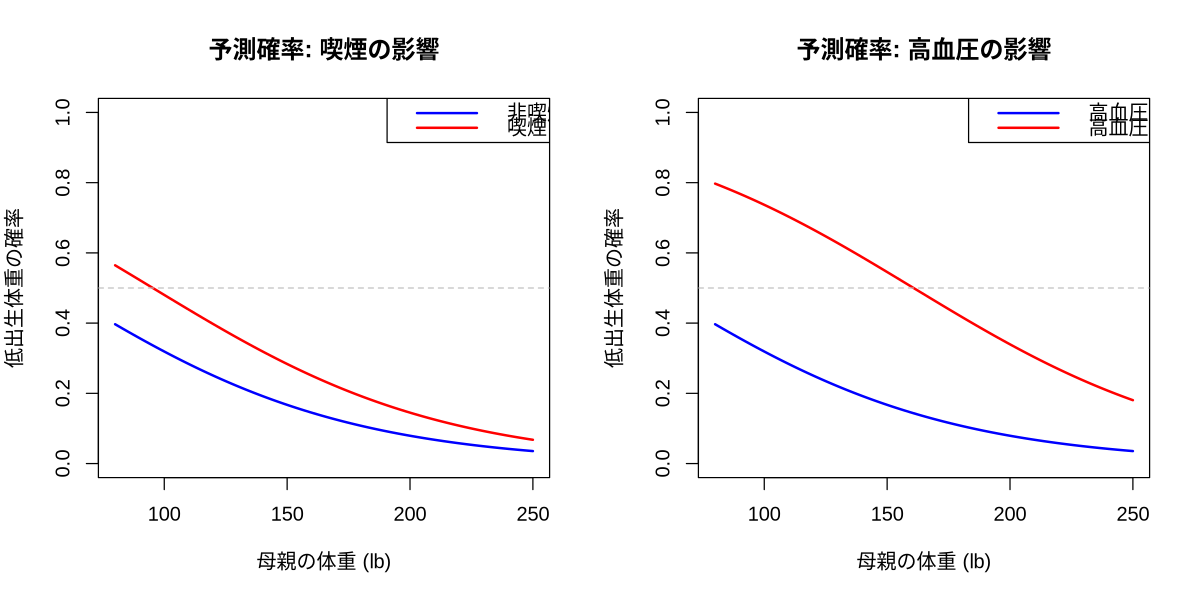

In [20]:
options(repr.plot.width=10, repr.plot.height=5)
par(mfrow=c(1,2))

lwt_seq <- seq(min(birthwt$lwt), max(birthwt$lwt), length.out=100)

# 喫煙者 vs 非喫煙者（年齢=平均、高血圧=なし）
pred_nonsmoker <- predict(fit_binom,
    newdata=data.frame(age=mean(birthwt$age), lwt=lwt_seq,
        smoke="非喫煙", ht="なし"),
    type="response")
pred_smoker <- predict(fit_binom,
    newdata=data.frame(age=mean(birthwt$age), lwt=lwt_seq,
        smoke="喫煙", ht="なし"),
    type="response")

plot(lwt_seq, pred_nonsmoker, type="l", col="blue", lwd=2, ylim=c(0, 1),
    main="予測確率: 喫煙の影響",
    xlab="母親の体重 (lb)", ylab="低出生体重の確率")
lines(lwt_seq, pred_smoker, col="red", lwd=2)
abline(h=0.5, lty=2, col="gray")
legend("topright", legend=c("非喫煙", "喫煙"),
    col=c("blue", "red"), lwd=2)

# 高血圧あり vs なし（年齢=平均、非喫煙）
pred_noht <- predict(fit_binom,
    newdata=data.frame(age=mean(birthwt$age), lwt=lwt_seq,
        smoke="非喫煙", ht="なし"),
    type="response")
pred_ht <- predict(fit_binom,
    newdata=data.frame(age=mean(birthwt$age), lwt=lwt_seq,
        smoke="非喫煙", ht="あり"),
    type="response")

plot(lwt_seq, pred_noht, type="l", col="blue", lwd=2, ylim=c(0, 1),
    main="予測確率: 高血圧の影響",
    xlab="母親の体重 (lb)", ylab="低出生体重の確率")
lines(lwt_seq, pred_ht, col="red", lwd=2)
abline(h=0.5, lty=2, col="gray")
legend("topright", legend=c("高血圧なし", "高血圧あり"),
    col=c("blue", "red"), lwd=2)

par(mfrow=c(1,1))

### 予測確率プロットの解釈

**左図（喫煙の影響）**:
- 赤線（喫煙）が青線（非喫煙）より常に上 → 喫煙は一貫してリスクを高める
- 体重が軽い母親ほど予測確率が高い → 体重の保護的効果が見える
- 体重80lb付近では喫煙者の確率が約0.5に達するが、体重が増えるとともに両群ともリスクが低下する

**右図（高血圧の影響）**:
- 赤線（高血圧あり）は青線（なし）に比べて大幅に上
- 高血圧の影響は喫煙より大きい（曲線間の距離がより広い）
- 高血圧＋低体重の母親は非常に高いリスクが予測される

---
# 3つのモデルの比較まとめ

| モデル | `family` | リンク関数 | 応答変数 | 係数の解釈 |
|--------|----------|------------|----------|------------|
| 線形回帰 | `gaussian` | 恒等 | 連続値 | そのまま差分 |
| ポアソン回帰 | `poisson` | 対数 | カウント | `exp()` → リスク比 |
| ロジスティック回帰 | `binomial` | ロジット | 二値(0/1) | `exp()` → オッズ比 |

### 共通点
- `glm()` の `family` を変えるだけで、同じ枠組みで異なる種類のデータを扱える
- `summary()` の構造は同じ（Estimate, Std. Error, 検定統計量, p値）
- `confint()` で信頼区間、`predict(type="response")` で予測値を得る

### 注意点
- `gaussian` 以外では、Estimate はリンク関数のスケールで出力される → 元のスケールに戻すには `exp()`（対数・ロジットリンクの場合）が必要
- ポアソン回帰では過分散に注意（Residual deviance / df >> 1）
- ロジスティック回帰ではオッズ比の信頼区間に1が含まれるか確認

# セッション情報

In [21]:
sessionInfo()

R version 4.5.3 (2026-03-11)
Platform: x86_64-conda-linux-gnu
Running under: Rocky Linux 9.5 (Blue Onyx)

Matrix products: default
BLAS/LAPACK: /home/koki/miniconda3/envs/r-notebook/lib/libopenblasp-r0.3.32.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Asia/Tokyo
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] MASS_7.3-65

loaded via a namespace (and not attached):
 [1] digest_0.6.39   IRdisplay_1.1   base64enc_0.1-6 fastmap_1.2.0  
 [5] glue_1.8.1      htmltools_0.5.9 repr_1.1.7      lifecycle_1.0.5
 [9] cli_3.6.6       vctrs_